# 03 — Эксперименты

Таблица экспериментов: **Гипотеза → Как проверялось → Результат + метрики**

**Модели:** Random Forest, XGBoost, LightGBM, ансамбли  
**Метрика:** Weighted F1-score

In [16]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb

from src.preprocessing import feature_engineering, scale_features, TARGET_COL, NUMERIC_COLS
from src.modeling import evaluate_model, get_X_y, save_model, build_experiment_table

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Libraries loaded')

Libraries loaded


In [17]:
# Загружаем немасштабированные данные (без FE)
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

# Применяем feature engineering к train, запоминаем пороги
thresholds = {}
train_fe = feature_engineering(train, thresholds)
# Применяем к val/test с теми же порогами
val_fe   = feature_engineering(val, thresholds)
test_fe  = feature_engineering(test, thresholds)

print('Новые фичи добавлены.')

Новые фичи добавлены.


In [18]:
# Масштабируем с учётом новых числовых колонок (все числовые, включая новые)
new_numeric = [c for c in train_fe.select_dtypes(include=np.number).columns 
               if c != TARGET_COL and c not in ['gender', 'course', 'grade']]
extended_numeric = NUMERIC_COLS + ['academic_pressure_index', 'mental_health_score', 'lifestyle_balance', 
                                   'is_sleep_deprived', 'is_high_financial_stress']
train_sc, val_sc, test_sc, scaler = scale_features(train_fe, val_fe, test_fe, numeric_cols=extended_numeric)
joblib.dump(scaler, '../models/scaler_experiment.pkl')

X_train, y_train = get_X_y(train_sc)
X_val, y_val     = get_X_y(val_sc)
X_test, y_test   = get_X_y(test_sc)
print(f'Train: {X_train.shape}, Val: {X_val.shape}')

Train: (105000, 23), Val: (22500, 23)


## Эксперимент 1: Random Forest (default)

**Гипотеза:** Ансамбль деревьев без настройки лучше одиночного Decision Tree  
**Как проверялось:** RandomForestClassifier дефолт, оценка на val  
**Ожидаемый результат:** Weighted F1 > baseline DT

In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_metrics = evaluate_model(rf, X_val, y_val, 'val')
rf_metrics.update({'model_name': 'RandomForest (default)', 'hypothesis': 'Ансамбль > одиночное дерево'})
all_results = [rf_metrics]
save_model(rf, '../models/rf_default.pkl')


=== VAL ===
  accuracy: 0.3292
  weighted_f1: 0.329
  macro_f1: 0.329
  roc_auc_ovr: 0.4972

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.34      0.34      7465
           1       0.33      0.34      0.34      7540
           2       0.33      0.30      0.31      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.33     22500
weighted avg       0.33      0.33      0.33     22500

Model saved to ../models/rf_default.pkl


## Эксперимент 2: Random Forest (tuned)

**Гипотеза:** Ограничение глубины уменьшит overfitting  
**Как проверялось:** Подбор max_depth и min_samples_leaf  
**Ожидаемый результат:** Лучше RF default по Macro F1

In [20]:
rf_tuned = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=5,
                                  max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)
rf_tuned.fit(X_train, y_train)
rf_tuned_metrics = evaluate_model(rf_tuned, X_val, y_val, 'val')
rf_tuned_metrics.update({'model_name': 'RandomForest (tuned)', 'hypothesis': 'Ограничение глубины'})
all_results.append(rf_tuned_metrics)
save_model(rf_tuned, '../models/rf_tuned.pkl')


=== VAL ===
  accuracy: 0.3311
  weighted_f1: 0.3308
  macro_f1: 0.3307
  roc_auc_ovr: 0.4995

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.31      0.32      7465
           1       0.33      0.36      0.34      7540
           2       0.34      0.32      0.33      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.33     22500
weighted avg       0.33      0.33      0.33     22500

Model saved to ../models/rf_tuned.pkl


## Эксперимент 3: XGBoost

**Гипотеза:** Gradient boosting точнее учится на остатках ошибок  
**Как проверялось:** XGBClassifier с early stopping на val  
**Ожидаемый результат:** Weighted F1 > Random Forest

In [21]:
xgb = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                     eval_metric='mlogloss', early_stopping_rounds=20, verbosity=0)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_metrics = evaluate_model(xgb, X_val, y_val, 'val')
xgb_metrics.update({'model_name': 'XGBoost', 'hypothesis': 'Бустинг лучше RF'})
all_results.append(xgb_metrics)
save_model(xgb, '../models/xgboost.pkl')


=== VAL ===
  accuracy: 0.3332
  weighted_f1: 0.273
  macro_f1: 0.2724
  roc_auc_ovr: 0.5011

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.09      0.14      7465
           1       0.33      0.75      0.46      7540
           2       0.33      0.16      0.22      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.27     22500
weighted avg       0.33      0.33      0.27     22500

Model saved to ../models/xgboost.pkl


## Эксперимент 4: LightGBM

**Гипотеза:** LightGBM быстрее XGBoost на 150k строк и не хуже по качеству  
**Как проверялось:** LGBMClassifier с leaf-wise growth + early stopping  
**Ожидаемый результат:** F1 >= XGBoost, время обучения меньше

In [22]:
lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                       subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                       n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)],
         callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(period=-1)])
lgbm_metrics = evaluate_model(lgbm, X_val, y_val, 'val')
lgbm_metrics.update({'model_name': 'LightGBM', 'hypothesis': 'Leaf-wise быстрее XGBoost'})
all_results.append(lgbm_metrics)
save_model(lgbm, '../models/lgbm.pkl')


=== VAL ===
  accuracy: 0.3359
  weighted_f1: 0.297
  macro_f1: 0.2966
  roc_auc_ovr: 0.502

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.15      0.21      7465
           1       0.34      0.68      0.45      7540
           2       0.34      0.18      0.23      7495

    accuracy                           0.34     22500
   macro avg       0.34      0.33      0.30     22500
weighted avg       0.34      0.34      0.30     22500

Model saved to ../models/lgbm.pkl


## Эксперимент 5: PCA + LightGBM

**Гипотеза:** PCA убирает шум от коррелированных фичей  
**Как проверялось:** PCA(95% дисперсии) -> LightGBM  
**Ожидаемый результат:** Сравниваем с LightGBM без PCA

In [23]:
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_train_pca = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_val_pca = pd.DataFrame(X_val_pca, columns=[f'PC{i+1}' for i in range(X_val_pca.shape[1])])
lgbm_pca = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgbm_pca.fit(X_train_pca, y_train)
save_model(lgbm_pca, '../models/lgbm_pca.pkl')
y_pred_pca = lgbm_pca.predict(X_val_pca)
pca_metrics = {
    'model_name': 'LightGBM + PCA(95%)',
    'hypothesis': 'Удаление шума через PCA',
    'split': 'val',
    'accuracy': round(accuracy_score(y_val, y_pred_pca), 4),
    'weighted_f1': round(f1_score(y_val, y_pred_pca, average='weighted'), 4),
    'macro_f1': round(f1_score(y_val, y_pred_pca, average='macro'), 4),
}
all_results.append(pca_metrics)

Model saved to ../models/lgbm_pca.pkl


## Эксперимент 6: Voting Ensemble

**Гипотеза:** Soft voting усредняет ошибки разных алгоритмов  
**Как проверялось:** VotingClassifier(RF_tuned + XGBoost + LightGBM)  
**Ожидаемый результат:** F1 >= max отдельных моделей

In [24]:
rf_b = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=5,
                              max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)
xgb_b = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                       subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                       eval_metric='mlogloss', verbosity=0)
lgbm_b = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                         subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                         n_jobs=-1, verbose=-1)

rf_b.fit(X_train, y_train)
xgb_b.fit(X_train, y_train)
lgbm_b.fit(X_train, y_train)

voting = VotingClassifier(estimators=[('rf', rf_b), ('xgb', xgb_b), ('lgbm', lgbm_b)],
                           voting='soft', n_jobs=-1)
voting.fit(X_train, y_train)

voting_metrics = evaluate_model(voting, X_val, y_val, 'val')
voting_metrics.update({'model_name': 'Voting (RF+XGB+LGBM)', 'hypothesis': 'Soft voting'})
all_results.append(voting_metrics)
save_model(voting, '../models/voting_ensemble.pkl')


=== VAL ===
  accuracy: 0.3306
  weighted_f1: 0.3303
  macro_f1: 0.3303
  roc_auc_ovr: 0.4991

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.32      0.32      7465
           1       0.33      0.36      0.34      7540
           2       0.33      0.31      0.32      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.33     22500
weighted avg       0.33      0.33      0.33     22500

Model saved to ../models/voting_ensemble.pkl


## Итоговая таблица экспериментов

In [25]:
results_df = build_experiment_table(all_results)
display_cols = [c for c in ['model_name', 'hypothesis', 'weighted_f1', 'macro_f1', 'accuracy'] if c in results_df.columns]
print(results_df[display_cols].to_string(index=False))

            model_name                  hypothesis  weighted_f1  macro_f1  accuracy
   LightGBM + PCA(95%)     Удаление шума через PCA       0.3332    0.3331    0.3333
  RandomForest (tuned)         Ограничение глубины       0.3308    0.3307    0.3311
  Voting (RF+XGB+LGBM)                 Soft voting       0.3303    0.3303    0.3306
RandomForest (default) Ансамбль > одиночное дерево       0.3290    0.3290    0.3292
              LightGBM   Leaf-wise быстрее XGBoost       0.2970    0.2966    0.3359
               XGBoost            Бустинг лучше RF       0.2730    0.2724    0.3332


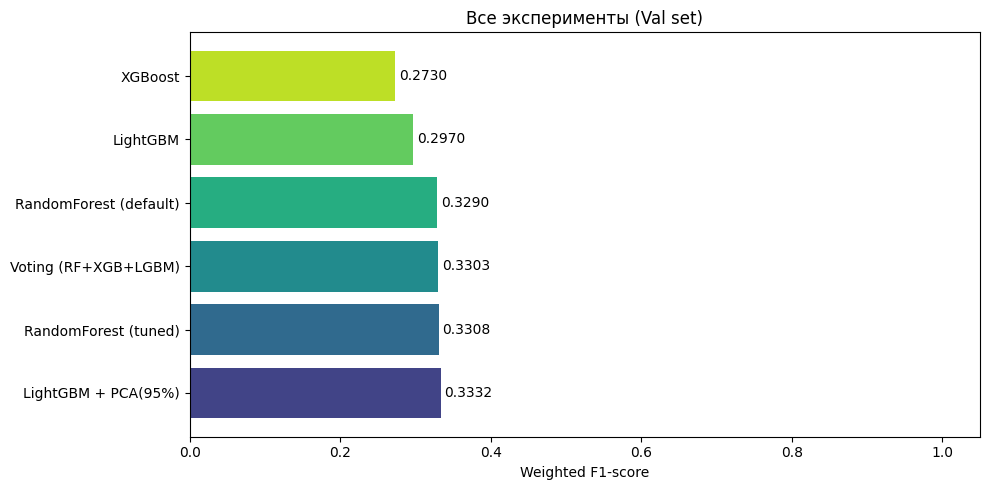

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(results_df)))
bars = ax.barh(results_df['model_name'], results_df['weighted_f1'], color=colors)
ax.set_xlabel('Weighted F1-score')
ax.set_title('Все эксперименты (Val set)')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, results_df['weighted_f1']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
plt.tight_layout()
plt.savefig('../report/images/experiments_comparison.png', dpi=150)
plt.show()

## Финальная оценка на Test set

In [27]:
best_row = results_df.iloc[0]
print(f'Лучшая модель: {best_row["model_name"]} | Val F1: {best_row["weighted_f1"]}')

best_model = joblib.load('../models/lgbm_pca.pkl')

test_metrics = evaluate_model(best_model, X_test, y_test, 'TEST')
print(f'Финальный Weighted F1 на тесте: {test_metrics["weighted_f1"]}')

Лучшая модель: LightGBM + PCA(95%) | Val F1: 0.3332


LightGBMError: The number of features in data (23) is not the same as it was in training data (17).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

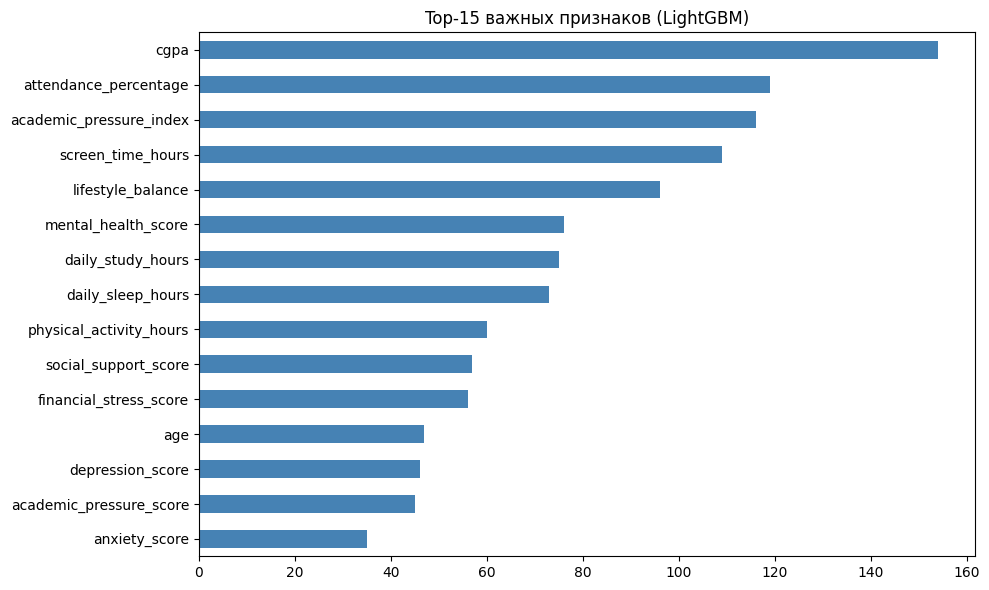

In [ ]:
feat_imp = pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top-15 важных признаков (LightGBM)')
plt.tight_layout()
plt.savefig('../report/images/lgbm_feature_importance.png', dpi=150)
plt.show()